<a href="https://colab.research.google.com/github/colab-patricio/Breast-Cancer-Segmentation/blob/main/breast_cancer_segmentation_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Ultrasound Tumour Segmentation — a Benchmark

**Dataset:** [BUSI](https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset) — 780 breast ultrasound scans with expert tumour masks, split across `benign`, `malignant` and `normal`.

**What this notebook does:** trains six segmentation architectures under identical
conditions, screens them on one fold, then cross-validates the finalists on a
held-out test set that no model ever trains or early-stops on.

## Why it is built this way

Segmentation results are easy to overstate. Four failure modes account for most
of it, and each one has a structural answer here:

| Failure mode | Answer |
|---|---|
| Validation set doubles as the test set | A test block held out before anything else; only `evaluate.py` reads it |
| Near-duplicate frames split across folds | Perceptual-hash grouping, enforced by an assertion |
| Masks resized bilinearly, left fractional | Nearest-neighbour + threshold, checked by a test |
| Qualitative results sampled from training data | Prediction figures read the test loader |

The code lives in `%%writefile` cells that build a small package on the Colab
disk, and a `pytest` cell verifies it before a single epoch runs. That keeps the
notebook self-contained without making it a wall of untested globals.

## Runtime budget

Set the runtime to **GPU** (`Runtime → Change runtime type → T4`).

The benchmark runs in two stages: six architectures screened on fold 0, then
5-fold cross-validation on the top three. Every run is keyed by
`{model}_fold{k}_seed{s}` and skipped if it already finished — if the session
dies, re-run the notebook and it continues where it stopped. Mounting Drive
(cell below, optional) makes that survive a full disconnect.

## 1. Environment

In [ ]:
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv

name, memory.total [MiB], compute_cap
Tesla T4, 15360 MiB, 7.5


In [ ]:
%pip install -q "monai>=1.4" einops
print("installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.0 MB/s eta 0:00:00
installed


In [ ]:
import torch

# Maxwell/Pascal GPUs are unsupported by CUDA 13+; fail loudly rather than
# halfway through the first epoch.
assert torch.cuda.is_available(), "No GPU. Runtime -> Change runtime type -> T4."
capability = torch.cuda.get_device_capability()
print(f"{torch.cuda.get_device_name(0)} | compute {capability[0]}.{capability[1]} | torch {torch.__version__}")
if capability < (7, 0):
    print("WARNING: no Tensor Cores; disable amp in the config below.")

Tesla T4 | compute 7.5 | torch 2.11.0+cu128


### Optional: persist runs to Google Drive

Skip this if you expect to finish in one sitting. With it, a disconnect costs
nothing — the next session finds the finished runs and resumes.

In [ ]:
USE_DRIVE = False  # set True to keep checkpoints across sessions

RUNS_DIR = "runs"
if USE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    RUNS_DIR = "/content/drive/MyDrive/busiseg/runs"

import os

os.makedirs(RUNS_DIR, exist_ok=True)
print("runs ->", RUNS_DIR)

runs -> runs


## 2. Get the data

Credentials come from **Colab Secrets** (the key icon in the left sidebar), so
nothing is uploaded and no credential file is written to disk. Add either:

- `KAGGLE_USERNAME` and `KAGGLE_KEY` as two separate secrets, or
- the whole contents of `kaggle.json` pasted into one secret named `kaggle.json`

and switch on **Notebook access** for each. A secret exists but stays
unreadable until that toggle is on, which is the usual cause of a failure here.

The values come from Kaggle -> Settings -> API -> *Create New Token*.

In [ ]:
%pip install -q kaggle

In [ ]:
import json
import os

from google.colab import userdata


def _secret(name: str) -> str | None:
    """Read one secret, returning None if it is absent or not shared."""
    try:
        return userdata.get(name)
    except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
        return None


def read_kaggle_credentials() -> tuple[str, str]:
    """Accept either two separate secrets or one holding the whole kaggle.json."""
    username, key = _secret("KAGGLE_USERNAME"), _secret("KAGGLE_KEY")

    if not key:
        for name in ("kaggle.json", "KAGGLE_JSON", "kaggle"):
            blob = _secret(name)
            if blob:
                parsed = json.loads(blob)
                username, key = parsed.get("username"), parsed.get("key")
                break

    if not (username and key):
        raise RuntimeError(
            "Kaggle credentials not found in Colab Secrets.\n\n"
            "Open the key icon in the left sidebar and add either\n"
            "  KAGGLE_USERNAME  +  KAGGLE_KEY\n"
            "or a single secret named 'kaggle.json' holding the file contents.\n"
            "Then switch on 'Notebook access' for each secret."
        )
    return username.strip(), key.strip()


# The Kaggle CLI reads these environment variables, so no credential file is
# written to disk and nothing survives the session.
os.environ["KAGGLE_USERNAME"], os.environ["KAGGLE_KEY"] = read_kaggle_credentials()

# Authenticate here rather than letting the download fail later: a bad key
# surfaces as a clear error now instead of a cryptic 401 mid-download.
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
print(f"authenticated as {os.environ['KAGGLE_USERNAME']}")

authenticated as alexandreotpatricio


In [ ]:
DATASET = "aryashah2k/breast-ultrasound-images-dataset"

!mkdir -p data
!kaggle datasets download -d {DATASET} -p data --unzip --quiet

# The archive nests the images one level deeper than its name suggests.
!find data -maxdepth 3 -type d -name "Dataset_BUSI_with_GT"

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
data/Dataset_BUSI_with_GT


In [ ]:
from pathlib import Path

RAW_DIR = next(Path("data").rglob("Dataset_BUSI_with_GT"))
for class_dir in sorted(RAW_DIR.iterdir()):
    if class_dir.is_dir():
        images = [p for p in class_dir.glob("*.png") if "_mask" not in p.name]
        masks = [p for p in class_dir.glob("*_mask*.png")]
        print(f"{class_dir.name:10s} {len(images):4d} images, {len(masks):4d} mask files")
print("\nraw dir:", RAW_DIR)

benign      437 images,  454 mask files
malignant   210 images,  211 mask files
normal      133 images,  133 mask files

raw dir: data/Dataset_BUSI_with_GT


## 3. Build the package

Ten `%%writefile` cells. Read them if you want to understand the pipeline; run
them and move on if you don't. The `pytest` cell at the end of this section is
the one that matters.

In [ ]:
import os

for directory in ["busiseg/data", "busiseg/models", "tests", "configs"]:
    os.makedirs(directory, exist_ok=True)
for package in ["busiseg", "busiseg/data", "busiseg/models", "tests"]:
    Path(package, "__init__.py").touch()
print("skeleton ready")

skeleton ready


### 3.1 Configuration and seeding

In [ ]:
%%writefile busiseg/config.py
"""Typed configuration loaded from YAML.

One dataclass per concern. `load_config` merges a YAML file over the defaults,
so a config file only needs to state what it changes.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass, field, fields, is_dataclass
from pathlib import Path
from typing import Any, get_type_hints

import yaml


@dataclass
class DataConfig:
    raw_dir: Path = Path("data/raw/Dataset_BUSI_with_GT")
    processed_dir: Path = Path("data/processed")
    manifest: Path = Path("data/processed/manifest.csv")
    splits: Path = Path("data/processed/splits.csv")
    image_size: int = 256
    classes: tuple[str, ...] = ("benign", "malignant", "normal")
    include_normal: bool = True
    """`normal` cases have empty masks. Keeping them teaches the model to predict
    nothing when there is nothing; they are scored separately (see metrics)."""


@dataclass
class SplitConfig:
    test_size: float = 0.15
    """Fraction held out entirely. Never used for training or model selection."""
    n_folds: int = 5
    """The remaining `dev` pool is divided into this many cross-validation folds."""
    seed: int = 42


@dataclass
class ModelConfig:
    name: str = "attention_unet"
    kwargs: dict[str, Any] = field(default_factory=dict)


@dataclass
class TrainConfig:
    epochs: int = 60
    batch_size: int = 8
    lr: float = 1e-3
    weight_decay: float = 1e-5
    patience: int = 12
    """Early stopping patience, in epochs, on validation Dice."""
    num_workers: int = 4
    amp: bool = True
    augment: bool = True
    device: str = "auto"


@dataclass
class Config:
    experiment: str = "default"
    seed: int = 42
    fold: int = 0
    """Which CV fold is the validation set for this run."""
    runs_dir: Path = Path("runs")
    data: DataConfig = field(default_factory=DataConfig)
    split: SplitConfig = field(default_factory=SplitConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    train: TrainConfig = field(default_factory=TrainConfig)


def _build(cls: type, values: dict[str, Any]) -> Any:
    """Instantiate `cls` from a dict, recursing into nested dataclasses.

    Type hints are resolved with `get_type_hints` rather than read off
    `field.type`: `from __future__ import annotations` turns those into strings,
    and a string never matches `is_dataclass`. Building generically matters —
    an earlier hand-written constructor silently dropped `fold`, so every
    cross-validation fold trained on fold 0.
    """
    hints = get_type_hints(cls)
    kwargs: dict[str, Any] = {}
    for f in fields(cls):
        if f.name not in values:
            continue
        hint, value = hints[f.name], values[f.name]
        if is_dataclass(hint) and isinstance(value, dict):
            kwargs[f.name] = _build(hint, value)
        elif hint is Path:
            kwargs[f.name] = Path(value)
        elif hint is tuple or getattr(hint, "__origin__", None) is tuple:
            kwargs[f.name] = tuple(value)
        else:
            kwargs[f.name] = value
    return cls(**kwargs)


def load_config(path: str | Path | None = None, **overrides: Any) -> Config:
    """Load a YAML config on top of the defaults.

    Nested sections merge one level deep, so a file may set only
    `train: {epochs: 5}` without restating the rest of the train block.
    """
    raw: dict[str, Any] = {}
    if path is not None:
        raw = yaml.safe_load(Path(path).read_text()) or {}

    merged = asdict(Config())
    for source in (raw, overrides):
        for key, value in source.items():
            if isinstance(value, dict) and isinstance(merged.get(key), dict):
                merged[key] = {**merged[key], **value}
            else:
                merged[key] = value

    return _build(Config, merged)


def to_dict(cfg: Config) -> dict[str, Any]:
    """Serialise a config to plain types, for logging alongside a run."""

    def convert(value: Any) -> Any:
        if isinstance(value, Path):
            return str(value)
        if isinstance(value, tuple):
            return list(value)
        if isinstance(value, dict):
            return {k: convert(v) for k, v in value.items()}
        return value

    return {k: convert(v) for k, v in asdict(cfg).items()}

Writing busiseg/config.py


In [ ]:
%%writefile busiseg/seeding.py
"""Reproducibility helpers."""

from __future__ import annotations

import random

import numpy as np
import torch


def set_seed(seed: int, deterministic: bool = True) -> None:
    """Seed every RNG the training loop touches.

    `deterministic=True` disables cuDNN autotuning, which costs some speed but
    makes two runs of the same config comparable — the point of a benchmark.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic


def resolve_device(spec: str = "auto") -> torch.device:
    if spec != "auto":
        return torch.device(spec)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

Writing busiseg/seeding.py


### 3.2 Preprocessing

Reads the raw download, merges the per-tumour masks into one, and writes a
derived dataset. The raw directory is never modified — the original notebook
wrote merged masks back next to the source images, which meant a second run
consumed its own output and a stray cleanup cell could silently delete a whole
class.

In [ ]:
%%writefile busiseg/data/preprocess.py
"""Turn the raw BUSI download into a clean, immutable derived dataset.

The raw directory is read-only here on purpose. The original notebook wrote the
merged masks back next to the source images, which made the pipeline
non-idempotent (re-running picked up its own output) and impossible to
reproduce from a clean checkout.

Output layout::

    processed_dir/
        images/<class>_<n>.png     grayscale sonogram
        masks/<class>_<n>.png      binary mask, 0 or 255
        manifest.csv               one row per case

A case may have several `*_mask_k.png` files (one tumour each); they are merged
with a logical OR into a single mask.
"""

from __future__ import annotations

import argparse
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

from busiseg.config import Config, load_config

MASK_PATTERN = re.compile(r"^(?P<stem>.+?)_mask(?:_\d+)?$")


def _case_stem(path: Path) -> str | None:
    """Return the case name for a mask file, or None if it is not a mask."""
    match = MASK_PATTERN.match(path.stem)
    return match.group("stem") if match else None


def group_cases(class_dir: Path) -> dict[str, list[Path]]:
    """Map each case stem to its list of mask files, sorted for determinism."""
    groups: dict[str, list[Path]] = defaultdict(list)
    for path in sorted(class_dir.glob("*.png")):
        stem = _case_stem(path)
        if stem is not None:
            groups[stem].append(path)
    return {stem: sorted(paths) for stem, paths in sorted(groups.items())}


def merge_masks(paths: list[Path]) -> np.ndarray:
    """Union of one or more binary masks, as uint8 in {0, 255}.

    Uses a logical OR rather than `cv2.add`: addition happens to saturate at 255
    for this data, but only because the masks are already saturated. OR states
    the intent and cannot overflow.
    """
    merged: np.ndarray | None = None
    for path in paths:
        mask = np.array(Image.open(path).convert("L")) > 127
        merged = mask if merged is None else (merged | mask)
    if merged is None:
        raise ValueError("no mask files given")
    return (merged.astype(np.uint8)) * 255


def dhash(image: Image.Image, size: int = 8) -> str:
    """Difference hash — a cheap perceptual fingerprint for duplicate detection.

    BUSI contains near-identical frames of the same lesion. If those land on
    both sides of a split the test score is inflated, so cases are grouped by
    hash before splitting (see `data.splits`).
    """
    resized = np.array(image.convert("L").resize((size + 1, size), Image.LANCZOS), dtype=np.int16)
    bits = (resized[:, 1:] > resized[:, :-1]).flatten()
    value = int("".join("1" if b else "0" for b in bits), 2)
    return f"{value:0{size * size // 4}x}"


def build(cfg: Config) -> pd.DataFrame:
    """Write the derived dataset and return its manifest."""
    raw_dir, out_dir = Path(cfg.data.raw_dir), Path(cfg.data.processed_dir)
    (out_dir / "images").mkdir(parents=True, exist_ok=True)
    (out_dir / "masks").mkdir(parents=True, exist_ok=True)

    rows = []
    for label in cfg.data.classes:
        class_dir = raw_dir / label
        if not class_dir.is_dir():
            raise FileNotFoundError(f"missing class directory: {class_dir}")

        for stem, mask_paths in group_cases(class_dir).items():
            image_path = class_dir / f"{stem}.png"
            if not image_path.exists():
                # A mask without its sonogram is unusable; skip loudly rather
                # than silently shifting the image/mask alignment.
                print(f"[warn] mask without image, skipping: {stem}")
                continue

            image = Image.open(image_path).convert("L")
            mask = merge_masks(mask_paths)
            case_id = stem.replace(" ", "_").replace("(", "").replace(")", "")

            image.save(out_dir / "images" / f"{case_id}.png")
            Image.fromarray(mask).save(out_dir / "masks" / f"{case_id}.png")

            rows.append(
                {
                    "case_id": case_id,
                    "label": label,
                    "image": f"images/{case_id}.png",
                    "mask": f"masks/{case_id}.png",
                    "n_masks": len(mask_paths),
                    "height": image.height,
                    "width": image.width,
                    "tumour_pixels": int((mask > 0).sum()),
                    "phash": dhash(image),
                }
            )

    manifest = pd.DataFrame(rows).sort_values("case_id").reset_index(drop=True)
    manifest.to_csv(cfg.data.manifest, index=False)
    return manifest


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--config", default="configs/base.yaml")
    args = parser.parse_args()

    cfg = load_config(args.config)
    manifest = build(cfg)
    empty = (manifest["tumour_pixels"] == 0).sum()
    print(f"{len(manifest)} cases -> {cfg.data.manifest}")
    print(manifest["label"].value_counts().to_string())
    print(f"empty masks: {empty}")


if __name__ == "__main__":
    main()

Writing busiseg/data/preprocess.py


### 3.3 Splits and folds

A test block held out first, then the remaining pool cut into 5 folds. Both
levels are stratified by class and grouped by perceptual hash, so near-duplicate
frames cannot straddle a boundary.

In [ ]:
%%writefile busiseg/data/splits.py
"""Build a duplicate-safe, stratified split with cross-validation folds.

Two levels:

* A **test** set (`split == "test"`) held out once and never touched until the
  final evaluation. It is identical for every model and every fold, so all
  reported numbers are comparable.
* A **dev** pool (`split == "dev"`) divided into `n_folds` folds. Training on
  fold *k* uses fold *k* as validation and the rest as training data.

Both levels respect duplicate groups: near-identical BUSI frames never straddle
a boundary, so a model cannot be scored on an image it effectively memorised.
"""

from __future__ import annotations

import argparse

import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

from busiseg.config import Config, load_config

HAMMING_THRESHOLD = 5
"""Max differing bits between two 64-bit dhashes to call them duplicates."""


def duplicate_groups(hashes: pd.Series, threshold: int = HAMMING_THRESHOLD) -> pd.Series:
    """Assign a group id per case, merging near-duplicate images.

    Union-find over pairwise Hamming distance. The dataset is ~800 cases, so the
    quadratic comparison is cheap and not worth an index structure.
    """
    values = [int(str(h), 16) for h in hashes]
    parent = list(range(len(values)))

    def find(i: int) -> int:
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    for i in range(len(values)):
        for j in range(i + 1, len(values)):
            if (values[i] ^ values[j]).bit_count() <= threshold:
                parent[find(i)] = find(j)

    return pd.Series([find(i) for i in range(len(values))], index=hashes.index, name="group")


def build(cfg: Config) -> pd.DataFrame:
    """Write `splits.csv` with a `split` column and, for dev rows, a `fold`."""
    manifest = pd.read_csv(cfg.data.manifest, dtype={"phash": str})
    if not cfg.data.include_normal:
        manifest = manifest[manifest["label"] != "normal"]
    manifest = manifest.reset_index(drop=True)
    manifest["group"] = duplicate_groups(manifest["phash"])

    # Hold out the test set first, so every fold trains on the same pool.
    n_test_splits = max(2, round(1 / cfg.split.test_size))
    outer = StratifiedGroupKFold(n_splits=n_test_splits, shuffle=True, random_state=cfg.split.seed)
    dev_idx, test_idx = next(outer.split(manifest, manifest["label"], groups=manifest["group"]))

    dev = manifest.iloc[dev_idx].reset_index(drop=True).assign(split="dev", fold=-1)
    test = manifest.iloc[test_idx].reset_index(drop=True).assign(split="test", fold=-1)

    inner = StratifiedGroupKFold(
        n_splits=cfg.split.n_folds, shuffle=True, random_state=cfg.split.seed
    )
    for fold, (_, val_idx) in enumerate(inner.split(dev, dev["label"], groups=dev["group"])):
        dev.loc[val_idx, "fold"] = fold

    splits = pd.concat([dev, test]).sort_values("case_id").reset_index(drop=True)
    _validate(splits, cfg.split.n_folds)
    splits.to_csv(cfg.data.splits, index=False)
    return splits


def _partition(splits: pd.DataFrame) -> pd.Series:
    """Label each case by the block it belongs to: 'test' or a fold number."""
    return splits["split"].where(splits["split"] == "test", "fold " + splits["fold"].astype(str))


def _validate(splits: pd.DataFrame, n_folds: int) -> None:
    assert splits["case_id"].is_unique, "a case appears more than once"
    assert (splits.loc[splits["split"] == "dev", "fold"] >= 0).all(), "dev case without a fold"

    # A duplicate group must live entirely inside one block.
    blocks = _partition(splits)
    leaked = splits.assign(block=blocks).groupby("group")["block"].nunique() > 1
    if leaked.any():
        raise AssertionError(f"{int(leaked.sum())} duplicate groups straddle a fold boundary")

    for fold in range(n_folds):
        if not (splits["fold"] == fold).any():
            raise AssertionError(f"fold {fold} is empty")


def summarise(splits: pd.DataFrame) -> pd.DataFrame:
    """Case counts per block and class, for the report."""
    return pd.crosstab(_partition(splits), splits["label"])


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--config", default="configs/base.yaml")
    args = parser.parse_args()

    cfg = load_config(args.config)
    splits = build(cfg)
    print(summarise(splits).to_string())
    print(f"\nduplicate groups: {splits['group'].nunique()} for {len(splits)} cases")
    print(f"written to {cfg.data.splits}")


if __name__ == "__main__":
    main()

Writing busiseg/data/splits.py


### 3.4 Dataset pipeline

MONAI transforms. Images resize bilinearly, masks resize with nearest-neighbour
and are re-thresholded after every geometric operation — including after
augmentation, which can otherwise reintroduce fractional values.

In [ ]:
%%writefile busiseg/data/dataset.py
"""MONAI transform pipeline and dataloaders.

Two decisions here fix bugs from the original notebook:

* **Masks are resized with nearest-neighbour and then thresholded.** Bilinear
  resizing produced fractional ground-truth values along tumour borders, which
  is not a valid target for a binary loss.
* **Images are referenced by path, not held as one big array.** Loading all
  1578 cases into a float64 array cost ~2.4 GB; `CacheDataset` caches the
  deterministic prefix of the pipeline and applies augmentation on the fly.
"""

from __future__ import annotations

from pathlib import Path

import pandas as pd
from monai.data import CacheDataset, DataLoader, list_data_collate
from monai.transforms import (
    AsDiscreted,
    Compose,
    EnsureChannelFirstd,
    Lambdad,
    LoadImaged,
    RandAdjustContrastd,
    RandAffined,
    RandFlipd,
    RandGaussianNoised,
    Resized,
    ScaleIntensityRanged,
    Transform,
)

from busiseg.config import Config

KEYS = ("image", "mask")


def base_transforms(image_size: int) -> list[Transform]:
    """Deterministic part of the pipeline — cacheable, shared by every split."""
    return [
        LoadImaged(keys=KEYS, image_only=True),
        EnsureChannelFirstd(keys=KEYS, channel_dim="no_channel"),
        Resized(keys=["image"], spatial_size=(image_size, image_size), mode="bilinear"),
        Resized(keys=["mask"], spatial_size=(image_size, image_size), mode="nearest"),
        ScaleIntensityRanged(keys=KEYS, a_min=0.0, a_max=255.0, b_min=0.0, b_max=1.0, clip=True),
        AsDiscreted(keys=["mask"], threshold=0.5),
    ]


def augmentations() -> list[Transform]:
    """Geometric and photometric jitter, applied identically to image and mask.

    No vertical flip or 90-degree rotation: ultrasound has a fixed probe-to-depth
    orientation, so those produce anatomically impossible images.
    """
    return [
        RandFlipd(keys=KEYS, prob=0.5, spatial_axis=1),
        RandAffined(
            keys=KEYS,
            prob=0.5,
            rotate_range=0.26,  # ~15 degrees
            scale_range=(0.1, 0.1),
            translate_range=(16, 16),
            mode=("bilinear", "nearest"),
            padding_mode="zeros",
        ),
        RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.4)),
        RandGaussianNoised(keys=["image"], prob=0.2, std=0.03),
        # Noise and gamma can push intensities outside [0, 1], and affine
        # resampling can leave fractional values in the mask. Restore both
        # invariants so the model's input domain never drifts.
        Lambdad(keys=["image"], func=lambda x: x.clamp(0.0, 1.0)),
        AsDiscreted(keys=["mask"], threshold=0.5),
    ]


def build_transforms(image_size: int, augment: bool) -> Compose:
    steps = base_transforms(image_size)
    if augment:
        steps += augmentations()
    return Compose(steps)


def records(cfg: Config, split: str) -> list[dict[str, str]]:
    """Rows of the split manifest as absolute paths MONAI can load.

    `split` is "train", "val" or "test". The first two are carved out of the
    dev pool by the current fold: fold `cfg.fold` is validation, the rest train.
    """
    frame = pd.read_csv(cfg.data.splits)
    if split == "test":
        frame = frame[frame["split"] == "test"]
    elif split == "val":
        frame = frame[(frame["split"] == "dev") & (frame["fold"] == cfg.fold)]
    elif split == "train":
        frame = frame[(frame["split"] == "dev") & (frame["fold"] != cfg.fold)]
    else:
        raise ValueError(f"unknown split {split!r}")
    root = Path(cfg.data.processed_dir)
    return [
        {
            "image": str(root / row.image),
            "mask": str(root / row.mask),
            "case_id": row.case_id,
            "label": row.label,
        }
        for row in frame.itertuples()
    ]


def build_loader(
    cfg: Config,
    split: str,
    shuffle: bool | None = None,
    cache_rate: float = 1.0,
) -> DataLoader:
    """Dataloader for one split. Augmentation applies to `train` only."""
    augment = cfg.train.augment and split == "train"
    dataset = CacheDataset(
        data=records(cfg, split),
        transform=build_transforms(cfg.data.image_size, augment),
        cache_rate=cache_rate,
        num_workers=cfg.train.num_workers,
        progress=False,
    )
    return DataLoader(
        dataset,
        batch_size=cfg.train.batch_size,
        shuffle=split == "train" if shuffle is None else shuffle,
        num_workers=cfg.train.num_workers,
        collate_fn=list_data_collate,
        pin_memory=False,
        drop_last=split == "train" and len(dataset) > cfg.train.batch_size,
    )

Writing busiseg/data/dataset.py


### 3.5 Models

Six architectures behind one `build_model()`. All are MONAI networks: 2D, one
input channel, one output logit channel.

In [ ]:
%%writefile busiseg/models/registry.py
"""Model registry for the benchmark.

Every architecture is a MONAI network configured for 2D, 1 input channel, 1
output channel (logits — the loss applies the sigmoid). Writing them by hand
was the notebook's approach and it produced an attention gate that diverged
from Oktay et al. 2018; MONAI's implementations are tested and cited.

Add an architecture by adding one entry to `BUILDERS`.
"""

from __future__ import annotations

from collections.abc import Callable
from typing import Any

import torch.nn as nn
from monai.networks.nets import (
    AttentionUnet,
    BasicUNetPlusPlus,
    FlexibleUNet,
    SegResNet,
    SwinUNETR,
    UNet,
)

IN_CHANNELS = 1
OUT_CHANNELS = 1


def _unet(**kwargs: Any) -> nn.Module:
    """Plain U-Net — the baseline the notebook promised but never trained."""
    defaults = dict(
        spatial_dims=2,
        in_channels=IN_CHANNELS,
        out_channels=OUT_CHANNELS,
        channels=(32, 64, 128, 256, 512),
        strides=(2, 2, 2, 2),
        num_res_units=2,
        dropout=0.1,
    )
    return UNet(**{**defaults, **kwargs})


def _attention_unet(**kwargs: Any) -> nn.Module:
    """Attention U-Net, faithful to the original paper."""
    defaults = dict(
        spatial_dims=2,
        in_channels=IN_CHANNELS,
        out_channels=OUT_CHANNELS,
        channels=(32, 64, 128, 256, 512),
        strides=(2, 2, 2, 2),
        dropout=0.1,
    )
    return AttentionUnet(**{**defaults, **kwargs})


def _unetpp(**kwargs: Any) -> nn.Module:
    defaults = dict(
        spatial_dims=2,
        in_channels=IN_CHANNELS,
        out_channels=OUT_CHANNELS,
        features=(32, 32, 64, 128, 256, 32),
        dropout=0.1,
    )
    return BasicUNetPlusPlus(**{**defaults, **kwargs})


def _segresnet(**kwargs: Any) -> nn.Module:
    defaults = dict(
        spatial_dims=2,
        in_channels=IN_CHANNELS,
        out_channels=OUT_CHANNELS,
        init_filters=32,
        dropout_prob=0.1,
    )
    return SegResNet(**{**defaults, **kwargs})


def _effnet_unet(**kwargs: Any) -> nn.Module:
    """U-Net with an ImageNet-pretrained EfficientNet encoder.

    Transfer learning is the highest-value change for a dataset this small.
    The encoder wants 3 channels, so the grey sonogram is repeated — see
    `expects_rgb`.
    """
    defaults = dict(
        in_channels=3,
        out_channels=OUT_CHANNELS,
        backbone="efficientnet-b0",
        pretrained=True,
        spatial_dims=2,
    )
    return FlexibleUNet(**{**defaults, **kwargs})


def _swin_unetr(**kwargs: Any) -> nn.Module:
    """Transformer encoder (Swin) with a U-Net decoder."""
    defaults = dict(
        spatial_dims=2,
        in_channels=IN_CHANNELS,
        out_channels=OUT_CHANNELS,
        feature_size=24,
        use_checkpoint=False,
    )
    return SwinUNETR(**{**defaults, **kwargs})


BUILDERS: dict[str, Callable[..., nn.Module]] = {
    "unet": _unet,
    "attention_unet": _attention_unet,
    "unetpp": _unetpp,
    "segresnet": _segresnet,
    "effnet_unet": _effnet_unet,
    "swin_unetr": _swin_unetr,
}

RGB_MODELS = frozenset({"effnet_unet"})


def build_model(name: str, **kwargs: Any) -> nn.Module:
    if name not in BUILDERS:
        raise KeyError(f"unknown model {name!r}; available: {sorted(BUILDERS)}")
    return BUILDERS[name](**kwargs)


def expects_rgb(name: str) -> bool:
    """Whether the model needs the single-channel input repeated to 3 channels."""
    return name in RGB_MODELS


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Writing busiseg/models/registry.py


### 3.6 Losses and metrics

Dice + cross-entropy for the loss. Metrics are computed per case on thresholded
predictions, so the report can show a distribution. Cases with an empty ground
truth return `NaN` rather than zero — a tumour-free scan has no defined Dice,
and they are reported instead as a false-positive rate.

In [ ]:
%%writefile busiseg/metrics.py
"""Segmentation losses and metrics.

The notebook reported `MeanIoU(num_classes=2)` on a sigmoid output. That metric
expects integer class labels, so continuous probabilities were cast to zero and
the curve mostly tracked the background class. Everything here operates on
thresholded predictions and is computed per sample, so the report can show a
distribution rather than a single mean.
"""

from __future__ import annotations

import numpy as np
import torch
from monai.losses import DiceCELoss, DiceFocalLoss, TverskyLoss

EPS = 1e-7


def build_loss(name: str = "dice_ce", **kwargs) -> torch.nn.Module:
    """Dice+CE by default: plain BCE under-weights the tumour, which occupies a
    small fraction of pixels, and drives the model toward predicting background.
    """
    losses = {
        "dice_ce": lambda: DiceCELoss(sigmoid=True, **kwargs),
        "dice_focal": lambda: DiceFocalLoss(sigmoid=True, **kwargs),
        # alpha < beta penalises false negatives harder — useful when recall on
        # small lesions matters more than boundary precision.
        "tversky": lambda: TverskyLoss(sigmoid=True, alpha=0.3, beta=0.7, **kwargs),
    }
    if name not in losses:
        raise KeyError(f"unknown loss {name!r}; available: {sorted(losses)}")
    return losses[name]()


def _flatten(x: torch.Tensor) -> torch.Tensor:
    return x.reshape(x.shape[0], -1)


@torch.no_grad()
def per_sample_scores(
    logits: torch.Tensor, target: torch.Tensor, threshold: float = 0.5
) -> dict[str, np.ndarray]:
    """Dice, IoU, precision and recall for each sample in the batch.

    Cases with an empty ground truth (the `normal` class) have an undefined
    Dice: any nonzero prediction scores 0 and a perfect prediction scores 0/0.
    They are returned as NaN and reported separately via `false_positive_rate`.
    """
    pred = (torch.sigmoid(logits) > threshold).float()
    pred, target = _flatten(pred), _flatten(target)

    intersection = (pred * target).sum(1)
    pred_sum, target_sum = pred.sum(1), target.sum(1)
    union = pred_sum + target_sum - intersection

    dice = (2 * intersection) / (pred_sum + target_sum + EPS)
    iou = intersection / (union + EPS)
    precision = intersection / (pred_sum + EPS)
    recall = intersection / (target_sum + EPS)

    empty = target_sum == 0
    scores = {"dice": dice, "iou": iou, "precision": precision, "recall": recall}
    out = {k: v.masked_fill(empty, float("nan")).cpu().numpy() for k, v in scores.items()}
    out["empty_target"] = empty.cpu().numpy()
    out["predicted_pixels"] = pred_sum.cpu().numpy()
    return out


def false_positive_rate(predicted_pixels: np.ndarray, empty_target: np.ndarray) -> float:
    """Fraction of tumour-free cases where the model predicted any tumour pixel."""
    if empty_target.sum() == 0:
        return float("nan")
    return float((predicted_pixels[empty_target] > 0).mean())


def bootstrap_ci(
    values: np.ndarray, n_resamples: int = 2000, alpha: float = 0.05, seed: int = 0
) -> tuple[float, float]:
    """Percentile bootstrap CI for the mean, ignoring NaNs.

    A single split gives one number; the interval is what makes two models in
    the benchmark actually comparable.
    """
    clean = values[~np.isnan(values)]
    if clean.size == 0:
        return (float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    means = rng.choice(clean, size=(n_resamples, clean.size), replace=True).mean(axis=1)
    return (float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2)))

Writing busiseg/metrics.py


### 3.7 Tracking, training, evaluation

In [ ]:
%%writefile busiseg/tracking.py
"""Minimal experiment tracking: one directory per run, plain files inside.

Deliberately not a framework. A run directory is self-describing (config,
metrics, checkpoint) and diffable, which is enough for a benchmark. MLflow is
picked up automatically when installed and `MLFLOW_TRACKING_URI` is set.
"""

from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import yaml


class RunLogger:
    """Writes `config.yaml`, `metrics.jsonl` and `summary.json` into a run dir."""

    def __init__(self, runs_dir: Path, name: str, config: dict[str, Any]):
        # The directory name is derived from the run's identity, not the clock,
        # so an interrupted session can find and skip work it already finished.
        self.dir = Path(runs_dir) / name
        self.dir.mkdir(parents=True, exist_ok=True)
        (self.dir / "config.yaml").write_text(yaml.safe_dump(config, sort_keys=False))
        self._metrics_path = self.dir / "metrics.jsonl"
        self._metrics_path.unlink(missing_ok=True)
        self._mlflow = self._start_mlflow(name, config)

    @staticmethod
    def _start_mlflow(name: str, config: dict[str, Any]):
        if not os.environ.get("MLFLOW_TRACKING_URI"):
            return None
        try:
            import mlflow
        except ImportError:
            return None
        mlflow.start_run(run_name=name)
        mlflow.log_params({f"{k}": json.dumps(v) for k, v in config.items()})
        return mlflow

    def log_metrics(self, step: int, **metrics: float) -> None:
        record = {"step": step, **{k: float(v) for k, v in metrics.items()}}
        with self._metrics_path.open("a") as handle:
            handle.write(json.dumps(record) + "\n")
        if self._mlflow is not None:
            self._mlflow.log_metrics({k: v for k, v in record.items() if k != "step"}, step=step)

    def log_summary(self, summary: dict[str, Any]) -> None:
        (self.dir / "summary.json").write_text(json.dumps(summary, indent=2, default=str))
        if self._mlflow is not None:
            numeric = {k: v for k, v in summary.items() if isinstance(v, (int, float))}
            self._mlflow.log_metrics(numeric)

    @property
    def checkpoint_path(self) -> Path:
        return self.dir / "best.pt"

    @staticmethod
    def is_complete(runs_dir: Path, name: str) -> bool:
        """Whether this run already finished, so a resumed session can skip it."""
        run_dir = Path(runs_dir) / name
        return (run_dir / "summary.json").exists() and (run_dir / "best.pt").exists()

    def close(self) -> None:
        if self._mlflow is not None:
            self._mlflow.end_run()

Writing busiseg/tracking.py


In [ ]:
%%writefile busiseg/train.py
"""Training loop.

Model selection happens on the validation split and nowhere else. `evaluate.py`
is the only thing that touches the test split.
"""

from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
import torch
from torch.amp import GradScaler, autocast
from tqdm import tqdm

from busiseg.config import Config, load_config, to_dict
from busiseg.data.dataset import build_loader
from busiseg.metrics import build_loss, per_sample_scores
from busiseg.models.registry import build_model, count_parameters, expects_rgb
from busiseg.seeding import resolve_device, set_seed
from busiseg.tracking import RunLogger


def prepare_batch(
    batch: dict, device: torch.device, rgb: bool
) -> tuple[torch.Tensor, torch.Tensor]:
    images = batch["image"].to(device, non_blocking=True).float()
    masks = batch["mask"].to(device, non_blocking=True).float()
    if rgb and images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    return images, masks


def forward(model: torch.nn.Module, images: torch.Tensor) -> torch.Tensor:
    """Some MONAI nets return a list (deep supervision); keep the finest output."""
    output = model(images)
    return output[-1] if isinstance(output, (list, tuple)) else output


@torch.no_grad()
def evaluate_split(model, loader, loss_fn, device, rgb) -> dict[str, float]:
    model.eval()
    losses, dice = [], []
    for batch in loader:
        images, masks = prepare_batch(batch, device, rgb)
        logits = forward(model, images)
        losses.append(loss_fn(logits, masks).item())
        dice.append(per_sample_scores(logits, masks)["dice"])
    stacked = np.concatenate(dice) if dice else np.array([np.nan])
    return {"loss": float(np.mean(losses)), "dice": float(np.nanmean(stacked))}


def run_name(cfg: Config) -> str:
    """Stable identity for a run: same config -> same directory."""
    return f"{cfg.model.name}_fold{cfg.fold}_seed{cfg.seed}"


def train(cfg: Config, resume: bool = True) -> Path:
    """Train one model and return its run directory.

    With `resume=True` a run whose summary and checkpoint already exist is
    skipped. Colab sessions are killed mid-benchmark, and re-running the
    notebook should continue rather than start over.
    """
    name = run_name(cfg)
    if resume and RunLogger.is_complete(cfg.runs_dir, name):
        print(f"skip {name} (already complete)")
        return Path(cfg.runs_dir) / name

    set_seed(cfg.seed)
    device = resolve_device(cfg.train.device)
    rgb = expects_rgb(cfg.model.name)

    train_loader = build_loader(cfg, "train")
    val_loader = build_loader(cfg, "val")

    model = build_model(cfg.model.name, **cfg.model.kwargs).to(device)
    loss_fn = build_loss()
    optimiser = torch.optim.AdamW(
        model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=cfg.train.epochs)
    use_amp = cfg.train.amp and device.type == "cuda"
    scaler = GradScaler(device.type, enabled=use_amp)

    logger = RunLogger(cfg.runs_dir, name, to_dict(cfg))
    best_dice, best_epoch = -1.0, -1

    for epoch in range(cfg.train.epochs):
        model.train()
        epoch_loss = 0.0
        for batch in tqdm(train_loader, desc=f"epoch {epoch + 1}/{cfg.train.epochs}", leave=False):
            images, masks = prepare_batch(batch, device, rgb)
            optimiser.zero_grad(set_to_none=True)
            with autocast(device.type, enabled=use_amp):
                loss = loss_fn(forward(model, images), masks)
            scaler.scale(loss).backward()
            scaler.step(optimiser)
            scaler.update()
            epoch_loss += loss.item()

        scheduler.step()
        val = evaluate_split(model, val_loader, loss_fn, device, rgb)
        logger.log_metrics(
            epoch,
            train_loss=epoch_loss / max(len(train_loader), 1),
            val_loss=val["loss"],
            val_dice=val["dice"],
            lr=scheduler.get_last_lr()[0],
        )

        if val["dice"] > best_dice:
            best_dice, best_epoch = val["dice"], epoch
            torch.save(model.state_dict(), logger.checkpoint_path)
        elif epoch - best_epoch >= cfg.train.patience:
            print(f"early stop at epoch {epoch + 1} (best {best_dice:.4f} @ {best_epoch + 1})")
            break

    logger.log_summary(
        {
            "model": cfg.model.name,
            "fold": cfg.fold,
            "seed": cfg.seed,
            "parameters": count_parameters(model),
            "best_val_dice": best_dice,
            "best_epoch": best_epoch + 1,
            "epochs_run": epoch + 1,
        }
    )
    logger.close()
    return logger.dir


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--config", default="configs/base.yaml")
    parser.add_argument("--model", default=None, help="override model.name")
    parser.add_argument("--epochs", type=int, default=None)
    args = parser.parse_args()

    overrides = {}
    if args.model:
        overrides["model"] = {"name": args.model}
    if args.epochs:
        overrides["train"] = {"epochs": args.epochs}

    run_dir = train(load_config(args.config, **overrides))
    print(f"run: {run_dir}")


if __name__ == "__main__":
    main()

Writing busiseg/train.py


In [ ]:
%%writefile busiseg/evaluate.py
"""Test-set evaluation: per-case scores, bootstrap CIs, per-class breakdown.

Reports the distribution of Dice, not just its mean. A mean of 0.78 hides
whether the model is uniformly decent or excellent on large lesions and useless
on small ones — which is the clinically relevant question.
"""

from __future__ import annotations

import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml

from busiseg.config import Config, load_config
from busiseg.data.dataset import build_loader
from busiseg.metrics import bootstrap_ci, false_positive_rate, per_sample_scores
from busiseg.models.registry import build_model, expects_rgb
from busiseg.seeding import resolve_device
from busiseg.train import forward, prepare_batch


@torch.no_grad()
def predict_scores(cfg: Config, model: torch.nn.Module, split: str = "test") -> pd.DataFrame:
    """One row per case, with its scores and label."""
    device = resolve_device(cfg.train.device)
    rgb = expects_rgb(cfg.model.name)
    loader = build_loader(cfg, split, shuffle=False)

    model.to(device).eval()
    rows = []
    for batch in loader:
        images, masks = prepare_batch(batch, device, rgb)
        scores = per_sample_scores(forward(model, images), masks)
        for i, case_id in enumerate(batch["case_id"]):
            rows.append(
                {
                    "case_id": case_id,
                    "label": batch["label"][i],
                    **{k: v[i] for k, v in scores.items()},
                }
            )
    return pd.DataFrame(rows)


def summarise(scores: pd.DataFrame) -> dict:
    """Aggregate per-case scores into the numbers that go in the report."""
    lo, hi = bootstrap_ci(scores["dice"].to_numpy())
    summary = {
        "n_cases": len(scores),
        "dice_mean": float(np.nanmean(scores["dice"])),
        "dice_median": float(np.nanmedian(scores["dice"])),
        "dice_ci95": [lo, hi],
        "iou_mean": float(np.nanmean(scores["iou"])),
        "precision_mean": float(np.nanmean(scores["precision"])),
        "recall_mean": float(np.nanmean(scores["recall"])),
        "fp_rate_on_empty": false_positive_rate(
            scores["predicted_pixels"].to_numpy(), scores["empty_target"].to_numpy()
        ),
    }
    for label, group in scores.groupby("label"):
        if group["empty_target"].all():
            continue
        summary[f"dice_{label}"] = float(np.nanmean(group["dice"]))
    return summary


def load_run(run_dir: Path) -> tuple[Config, torch.nn.Module]:
    """Rebuild the config and weights of a finished run."""
    cfg = load_config(run_dir / "config.yaml")
    model = build_model(cfg.model.name, **cfg.model.kwargs)
    model.load_state_dict(torch.load(run_dir / "best.pt", map_location="cpu"))
    return cfg, model


def evaluate_run(run_dir: Path, split: str = "test") -> dict:
    cfg, model = load_run(run_dir)
    scores = predict_scores(cfg, model, split)
    scores.to_csv(run_dir / f"scores_{split}.csv", index=False)
    summary = summarise(scores)
    (run_dir / f"eval_{split}.json").write_text(json.dumps(summary, indent=2))
    return summary


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("run_dir", type=Path)
    parser.add_argument("--split", default="test")
    args = parser.parse_args()

    summary = evaluate_run(args.run_dir, args.split)
    print(yaml.safe_dump(summary, sort_keys=False))


if __name__ == "__main__":
    main()

Writing busiseg/evaluate.py


### 3.8 Benchmark and figures

In [ ]:
%%writefile busiseg/benchmark.py
"""Two-stage benchmark, sized for a single Colab session.

**Stage 1 — screening.** Every architecture trains once, on fold 0. Cheap, and
enough to separate the contenders from the rest.

**Stage 2 — cross-validation.** Only the top `n_finalists` are retrained on all
folds. The statistical budget goes where it changes a decision, instead of
producing a tight confidence interval for the model that came sixth.

Every run is keyed by `{model}_fold{k}_seed{s}` and skipped if already finished,
so a killed session resumes by simply re-running the same call.
"""

from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
import pandas as pd

from busiseg.config import Config, load_config
from busiseg.evaluate import evaluate_run
from busiseg.metrics import bootstrap_ci
from busiseg.models.registry import BUILDERS
from busiseg.train import train

DEFAULT_MODELS = ["unet", "attention_unet", "unetpp", "segresnet", "effnet_unet", "swin_unetr"]


def _train_and_score(cfg: Config) -> dict:
    run_dir = train(cfg)
    summary = evaluate_run(run_dir)
    return {"model": cfg.model.name, "fold": cfg.fold, "run_dir": str(run_dir), **summary}


def _config_for(
    config_path: str | Path, name: str, fold: int, per_model: dict[str, dict] | None
) -> Config:
    """Config for one architecture.

    The YAML's `model.kwargs` belongs to the architecture the YAML names, so it
    is dropped when the benchmark switches models — otherwise a U-Net's
    `channels` argument reaches SegResNet and the run dies mid-benchmark.
    Architecture-specific overrides go through `per_model` instead.
    """
    kwargs = (per_model or {}).get(name, {})
    return load_config(config_path, model={"name": name, "kwargs": kwargs}, fold=fold)


def screen(
    config_path: str | Path,
    models: list[str],
    fold: int = 0,
    per_model: dict[str, dict] | None = None,
) -> pd.DataFrame:
    """Stage 1: one run per architecture, ranked by test Dice."""
    rows = []
    for name in models:
        print(f"\n=== screening: {name} ===")
        rows.append(_train_and_score(_config_for(config_path, name, fold, per_model)))
    return pd.DataFrame(rows).sort_values("dice_mean", ascending=False).reset_index(drop=True)


def cross_validate(
    config_path: str | Path,
    models: list[str],
    n_folds: int,
    per_model: dict[str, dict] | None = None,
) -> pd.DataFrame:
    """Stage 2: every finalist on every fold."""
    rows = []
    for name in models:
        for fold in range(n_folds):
            print(f"\n=== cv: {name} fold {fold} ===")
            rows.append(_train_and_score(_config_for(config_path, name, fold, per_model)))
    return pd.DataFrame(rows)


def leaderboard(results: pd.DataFrame) -> pd.DataFrame:
    """Mean test Dice per architecture, with the spread across folds.

    The std here is across folds, i.e. how much the answer depends on which
    images happened to be used for training — a different and more honest
    question than the per-case confidence interval within one fold.
    """
    return (
        results.groupby("model")
        .agg(
            dice_mean=("dice_mean", "mean"),
            dice_std=("dice_mean", "std"),
            recall=("recall_mean", "mean"),
            precision=("precision_mean", "mean"),
            fp_rate=("fp_rate_on_empty", "mean"),
            n_folds=("fold", "count"),
        )
        .sort_values("dice_mean", ascending=False)
        .round(4)
    )


def pooled_case_scores(results: pd.DataFrame, model: str) -> pd.DataFrame:
    """Every test case scored by every fold's model, for one architecture."""
    frames = []
    for row in results[results["model"] == model].itertuples():
        scores = pd.read_csv(Path(row.run_dir) / "scores_test.csv")
        frames.append(scores.assign(fold=row.fold))
    return pd.concat(frames, ignore_index=True)


def fold_confidence_interval(results: pd.DataFrame, model: str) -> tuple[float, float]:
    """Bootstrap CI over the per-fold mean Dice of one architecture."""
    values = results.loc[results["model"] == model, "dice_mean"].to_numpy()
    return bootstrap_ci(np.asarray(values))


def run_benchmark(
    config_path: str | Path,
    models: list[str] | None = None,
    n_finalists: int = 3,
    out_dir: Path = Path("runs"),
    per_model: dict[str, dict] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Both stages. Returns (screening results, cross-validation results)."""
    cfg = load_config(config_path)
    models = models or DEFAULT_MODELS

    screening = screen(config_path, models, per_model=per_model)
    screening.to_csv(out_dir / "screening.csv", index=False)
    print("\n--- screening ---")
    print(screening[["model", "dice_mean", "recall_mean"]].round(4).to_string(index=False))

    finalists = screening["model"].head(n_finalists).tolist()
    print(f"\nfinalists: {finalists}")

    cv = cross_validate(config_path, finalists, cfg.split.n_folds, per_model=per_model)
    cv.to_csv(out_dir / "cross_validation.csv", index=False)
    print("\n--- cross-validation ---")
    print(leaderboard(cv).to_string())
    return screening, cv


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--config", default="configs/base.yaml")
    parser.add_argument("--models", nargs="+", default=DEFAULT_MODELS, choices=sorted(BUILDERS))
    parser.add_argument("--finalists", type=int, default=3)
    parser.add_argument("--out", type=Path, default=Path("runs"))
    args = parser.parse_args()

    args.out.mkdir(parents=True, exist_ok=True)
    run_benchmark(args.config, args.models, args.finalists, args.out)


if __name__ == "__main__":
    main()

Writing busiseg/benchmark.py


In [ ]:
%%writefile busiseg/report.py
"""Figures for the report section.

Every function takes data and returns a matplotlib Figure; none of them read
global state or call `plt.show()`, so they are usable from a notebook cell or a
script and are trivially testable.
"""

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from busiseg.config import Config
from busiseg.data.dataset import build_loader
from busiseg.models.registry import expects_rgb
from busiseg.train import forward, prepare_batch

TRAIN_COLOUR, VAL_COLOUR = "mediumseagreen", "darkorange"


def plot_samples(cfg: Config, split: str = "test", n: int = 4) -> plt.Figure:
    """Image, ground truth, and overlay for a few cases."""
    loader = build_loader(cfg, split, shuffle=False, cache_rate=0.0)
    batch = next(iter(loader))
    n = min(n, batch["image"].shape[0])

    fig, axes = plt.subplots(n, 3, figsize=(8, 2.6 * n), squeeze=False)
    for row in range(n):
        image = batch["image"][row, 0].numpy()
        mask = batch["mask"][row, 0].numpy()
        for col, (data, title, kwargs) in enumerate(
            [
                (image, "Sonogram", {"cmap": "gray"}),
                (mask, "Ground truth", {"cmap": "magma"}),
                (image, "Overlay", {"cmap": "gray"}),
            ]
        ):
            axes[row][col].imshow(data, **kwargs)
            if col == 2:
                axes[row][col].imshow(
                    np.ma.masked_where(mask < 0.5, mask), cmap="autumn", alpha=0.5
                )
            axes[row][col].set_title(f"{title} — {batch['label'][row]}" if row == 0 else "")
            axes[row][col].axis("off")
    fig.tight_layout()
    return fig


def plot_learning_curves(run_dirs: dict[str, Path]) -> plt.Figure:
    """Train loss, validation loss and validation Dice for one or more runs."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    for label, run_dir in run_dirs.items():
        metrics = pd.read_json(Path(run_dir) / "metrics.jsonl", lines=True)
        axes[0].plot(metrics["step"], metrics["train_loss"], label=label)
        axes[1].plot(metrics["step"], metrics["val_loss"], label=label)
        axes[2].plot(metrics["step"], metrics["val_dice"], label=label)

    for ax, title, ylabel in zip(
        axes,
        ["Training loss", "Validation loss", "Validation Dice"],
        ["Dice + CE", "Dice + CE", "Dice"],
        strict=True,
    ):
        ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
        ax.grid(alpha=0.3)
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    return fig


def plot_dice_distribution(scores: pd.DataFrame, by: str = "label") -> plt.Figure:
    """Boxplot of per-case Dice.

    The point of the report: a mean of 0.78 can be a model that is uniformly
    decent, or one that is excellent on large lesions and useless on small ones.
    Only the distribution distinguishes them.
    """
    groups = [g["dice"].dropna().to_numpy() for _, g in scores.groupby(by)]
    names = [str(name) for name, _ in scores.groupby(by)]

    fig, ax = plt.subplots(figsize=(1.6 * len(names) + 3, 4))
    ax.boxplot(groups, tick_labels=names, showmeans=True)
    for i, values in enumerate(groups, start=1):
        jitter = np.random.default_rng(0).normal(i, 0.04, len(values))
        ax.scatter(jitter, values, s=8, alpha=0.35, color="steelblue")
    ax.set(
        xlabel=by, ylabel="Dice", title="Per-case Dice on the held-out test set", ylim=(-0.02, 1.02)
    )
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    return fig


def plot_leaderboard(board: pd.DataFrame) -> plt.Figure:
    """Mean test Dice per architecture, with the across-fold spread as error bars."""
    fig, ax = plt.subplots(figsize=(7, 0.6 * len(board) + 1.5))
    y = np.arange(len(board))
    ax.barh(y, board["dice_mean"], xerr=board["dice_std"].fillna(0), color="steelblue", capsize=4)
    ax.set(
        yticks=y, yticklabels=board.index, xlabel="Test Dice", title="Cross-validated leaderboard"
    )
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    return fig


@torch.no_grad()
def plot_predictions(
    cfg: Config, model: torch.nn.Module, n: int = 4, threshold: float = 0.5
) -> plt.Figure:
    """Qualitative predictions — from the test split only.

    The original notebook sampled these from the full array, so most "results"
    were images the model had trained on.
    """
    device = next(model.parameters()).device
    loader = build_loader(cfg, "test", shuffle=False, cache_rate=0.0)
    batch = next(iter(loader))
    images, masks = prepare_batch(batch, device, expects_rgb(cfg.model.name))
    probabilities = torch.sigmoid(forward(model.eval(), images)).cpu()

    n = min(n, images.shape[0])
    fig, axes = plt.subplots(n, 4, figsize=(11, 2.6 * n), squeeze=False)
    titles = ["Sonogram", "Ground truth", "Probability", f"Prediction @ {threshold}"]
    for row in range(n):
        panels = [
            (batch["image"][row, 0].numpy(), "gray"),
            (masks[row, 0].cpu().numpy(), "magma"),
            (probabilities[row, 0].numpy(), "magma"),
            ((probabilities[row, 0].numpy() > threshold).astype(float), "magma"),
        ]
        for col, (data, cmap) in enumerate(panels):
            axes[row][col].imshow(data, cmap=cmap, vmin=0 if col else None, vmax=1 if col else None)
            axes[row][col].set_title(titles[col] if row == 0 else "")
            axes[row][col].axis("off")
        axes[row][0].set_ylabel(batch["label"][row])
    fig.tight_layout()
    return fig

Writing busiseg/report.py


### 3.9 Tests

In [ ]:
%%writefile tests/conftest.py
"""Shared fixtures: a miniature synthetic BUSI tree.

Tests must not depend on the real download. The generator reproduces the
structural quirks that matter — multi-mask cases, empty `normal` masks,
parenthesised filenames, and a pair of near-duplicate images.
"""

from __future__ import annotations

import numpy as np
import pytest
from PIL import Image

from busiseg.config import Config, DataConfig, SplitConfig, TrainConfig

CASES_PER_CLASS = 12


def _sonogram(rng: np.random.Generator, size: int = 64) -> np.ndarray:
    return rng.integers(20, 200, size=(size, size), dtype=np.uint8)


def _disc(size: int, cx: int, cy: int, radius: int) -> np.ndarray:
    yy, xx = np.ogrid[:size, :size]
    return (((xx - cx) ** 2 + (yy - cy) ** 2) <= radius**2).astype(np.uint8) * 255


@pytest.fixture
def raw_dataset(tmp_path):
    """Write a synthetic Dataset_BUSI_with_GT tree and return its path."""
    rng = np.random.default_rng(0)
    root = tmp_path / "raw" / "Dataset_BUSI_with_GT"

    for label in ("benign", "malignant", "normal"):
        class_dir = root / label
        class_dir.mkdir(parents=True)
        for i in range(1, CASES_PER_CLASS + 1):
            stem = f"{label} ({i})"
            Image.fromarray(_sonogram(rng)).save(class_dir / f"{stem}.png")

            if label == "normal":
                Image.fromarray(np.zeros((64, 64), np.uint8)).save(class_dir / f"{stem}_mask.png")
                continue

            Image.fromarray(_disc(64, 20, 20, 8)).save(class_dir / f"{stem}_mask.png")
            if i == 1:  # a case with two tumours, as BUSI has
                Image.fromarray(_disc(64, 45, 45, 6)).save(class_dir / f"{stem}_mask_1.png")

    # A near-duplicate of "benign (1)" — the split must keep them together.
    original = np.array(Image.open(root / "benign" / "benign (1).png"))
    Image.fromarray(original).save(root / "benign" / "benign (99).png")
    Image.fromarray(_disc(64, 20, 20, 8)).save(root / "benign" / "benign (99)_mask.png")

    return root


@pytest.fixture
def cfg(tmp_path, raw_dataset) -> Config:
    processed = tmp_path / "processed"
    processed.mkdir()
    return Config(
        experiment="test",
        runs_dir=tmp_path / "runs",
        data=DataConfig(
            raw_dir=raw_dataset,
            processed_dir=processed,
            manifest=processed / "manifest.csv",
            splits=processed / "splits.csv",
            image_size=32,
        ),
        split=SplitConfig(test_size=0.2, n_folds=3, seed=0),
        train=TrainConfig(epochs=1, batch_size=2, num_workers=0, amp=False, device="cpu"),
    )


@pytest.fixture
def prepared_cfg(cfg) -> Config:
    """A config whose manifest and splits have already been written."""
    from busiseg.data import preprocess, splits

    preprocess.build(cfg)
    splits.build(cfg)
    return cfg

Writing tests/conftest.py


In [ ]:
%%writefile tests/test_config.py
"""Tests for config loading.

These exist because a hand-written `Config(...)` constructor silently dropped
the `fold` field, so every cross-validation fold trained and early-stopped on
fold 0 while reporting distinct fold numbers. Nothing crashed; the results were
just quietly wrong. Round-tripping every top-level field is the guard.
"""

from __future__ import annotations

from dataclasses import fields
from pathlib import Path

import pytest
import yaml

from busiseg.config import Config, load_config, to_dict


@pytest.fixture
def config_file(tmp_path) -> Path:
    path = tmp_path / "cfg.yaml"
    path.write_text(yaml.safe_dump(to_dict(Config())))
    return path


class TestOverrides:
    @pytest.mark.parametrize("fold", [0, 1, 4])
    def test_fold_survives(self, config_file, fold):
        assert load_config(config_file, fold=fold).fold == fold

    def test_every_scalar_field_survives(self, config_file):
        """Guards against a new top-level field being added and not wired up."""
        probes = {"experiment": "probe", "seed": 123, "fold": 2}
        cfg = load_config(config_file, **probes)
        for name, value in probes.items():
            assert getattr(cfg, name) == value

    def test_no_top_level_field_is_unreachable(self, config_file):
        loaded = load_config(config_file)
        assert {f.name for f in fields(Config)} == set(to_dict(loaded))

    def test_nested_override_keeps_siblings(self, config_file):
        cfg = load_config(config_file, train={"epochs": 3})
        assert cfg.train.epochs == 3
        assert cfg.train.batch_size == Config().train.batch_size

    def test_model_kwargs_can_be_replaced(self, config_file):
        cfg = load_config(config_file, model={"name": "segresnet", "kwargs": {"init_filters": 8}})
        assert cfg.model.name == "segresnet"
        assert cfg.model.kwargs == {"init_filters": 8}


class TestTypes:
    def test_paths_are_path_objects(self, config_file):
        cfg = load_config(config_file)
        assert isinstance(cfg.runs_dir, Path)
        assert isinstance(cfg.data.processed_dir, Path)

    def test_classes_stay_a_tuple(self, config_file):
        assert isinstance(load_config(config_file).data.classes, tuple)

    def test_round_trip_is_stable(self, config_file, tmp_path):
        """Serialise -> write -> load must be a fixed point, or a resumed run
        would rebuild a different model than the one it checkpointed."""
        first = load_config(config_file, fold=3, model={"name": "unetpp"})
        path = tmp_path / "round.yaml"
        path.write_text(yaml.safe_dump(to_dict(first)))
        assert to_dict(load_config(path)) == to_dict(first)


class TestDefaults:
    def test_loads_without_a_file(self):
        assert to_dict(load_config()) == to_dict(Config())

    def test_missing_keys_fall_back(self, tmp_path):
        path = tmp_path / "partial.yaml"
        path.write_text("train:\n  epochs: 7\n")
        cfg = load_config(path)
        assert cfg.train.epochs == 7
        assert cfg.model.name == Config().model.name

Writing tests/test_config.py


In [ ]:
%%writefile tests/test_data.py
"""Tests for the data pipeline — the layer where the original bugs lived."""

from __future__ import annotations

import numpy as np
import pandas as pd
import pytest
from PIL import Image

from busiseg.data import preprocess, splits
from busiseg.data.dataset import build_loader, records


class TestPreprocess:
    def test_writes_one_row_per_case(self, cfg):
        manifest = preprocess.build(cfg)
        # 12 per class + 1 near-duplicate benign case
        assert len(manifest) == 37
        assert set(manifest["label"]) == {"benign", "malignant", "normal"}

    def test_merges_multiple_masks(self, cfg):
        manifest = preprocess.build(cfg)
        multi = manifest[manifest["n_masks"] == 2]
        single = manifest[(manifest["n_masks"] == 1) & (manifest["label"] == "benign")]
        assert len(multi) == 2  # one benign, one malignant
        assert multi["tumour_pixels"].min() > single["tumour_pixels"].max()

    def test_masks_are_strictly_binary(self, cfg):
        preprocess.build(cfg)
        for path in (cfg.data.processed_dir / "masks").glob("*.png"):
            values = np.unique(np.array(Image.open(path)))
            assert set(values.tolist()) <= {0, 255}

    def test_normal_cases_have_empty_masks(self, cfg):
        manifest = preprocess.build(cfg)
        normal = manifest[manifest["label"] == "normal"]
        assert (normal["tumour_pixels"] == 0).all()

    def test_is_idempotent(self, cfg):
        """Re-running must not pick up its own output — the notebook's bug."""
        first = preprocess.build(cfg)
        second = preprocess.build(cfg)
        pd.testing.assert_frame_equal(first, second)

    def test_does_not_write_into_raw(self, cfg):
        before = sorted(p.name for p in cfg.data.raw_dir.rglob("*.png"))
        preprocess.build(cfg)
        assert sorted(p.name for p in cfg.data.raw_dir.rglob("*.png")) == before

    def test_identical_images_share_a_hash(self, cfg):
        manifest = preprocess.build(cfg).set_index("case_id")
        assert manifest.loc["benign_1", "phash"] == manifest.loc["benign_99", "phash"]


class TestSplits:
    def test_covers_every_case_exactly_once(self, cfg):
        manifest = preprocess.build(cfg)
        frame = splits.build(cfg)
        assert len(frame) == len(manifest)
        assert frame["case_id"].is_unique
        assert set(frame["split"]) == {"dev", "test"}

    def test_every_dev_case_gets_a_fold(self, cfg):
        preprocess.build(cfg)
        frame = splits.build(cfg)
        dev = frame[frame["split"] == "dev"]
        assert set(dev["fold"]) == set(range(cfg.split.n_folds))
        assert (frame.loc[frame["split"] == "test", "fold"] == -1).all()

    def test_folds_partition_the_dev_pool(self, cfg):
        """Train and val must be disjoint and together cover dev, for every fold."""
        preprocess.build(cfg)
        frame = splits.build(cfg)
        dev = set(frame.loc[frame["split"] == "dev", "case_id"])
        for fold in range(cfg.split.n_folds):
            cfg.fold = fold
            train_ids = {r["case_id"] for r in records(cfg, "train")}
            val_ids = {r["case_id"] for r in records(cfg, "val")}
            assert not (train_ids & val_ids)
            assert train_ids | val_ids == dev

    def test_test_set_is_identical_across_folds(self, cfg):
        """The held-out set must not move, or fold scores are not comparable."""
        preprocess.build(cfg)
        splits.build(cfg)
        seen = []
        for fold in range(cfg.split.n_folds):
            cfg.fold = fold
            seen.append({r["case_id"] for r in records(cfg, "test")})
        assert all(s == seen[0] for s in seen)

    def test_duplicates_do_not_cross_splits(self, cfg):
        preprocess.build(cfg)
        frame = splits.build(cfg).set_index("case_id")
        assert frame.loc["benign_1", "split"] == frame.loc["benign_99", "split"]
        assert frame.loc["benign_1", "fold"] == frame.loc["benign_99", "fold"]

    def test_every_block_sees_every_class(self, cfg):
        preprocess.build(cfg)
        frame = splits.build(cfg)
        assert (splits.summarise(frame) > 0).all().all()

    def test_is_deterministic(self, cfg):
        preprocess.build(cfg)
        first = splits.build(cfg)
        second = splits.build(cfg)
        pd.testing.assert_frame_equal(first, second)

    def test_excluding_normal_drops_empty_masks(self, cfg):
        preprocess.build(cfg)
        cfg.data.include_normal = False
        frame = splits.build(cfg)
        assert "normal" not in set(frame["label"])


class TestDataset:
    def test_batch_shapes_and_range(self, prepared_cfg):
        loader = build_loader(prepared_cfg, "train", cache_rate=0.0)
        batch = next(iter(loader))
        size = prepared_cfg.data.image_size
        assert batch["image"].shape[1:] == (1, size, size)
        assert batch["mask"].shape[1:] == (1, size, size)
        assert batch["image"].min() >= 0.0 and batch["image"].max() <= 1.0

    def test_masks_stay_binary_after_resize_and_augmentation(self, prepared_cfg):
        """Bilinear resizing of a mask produced fractional targets in the
        original notebook; nearest + threshold must keep them in {0, 1}."""
        loader = build_loader(prepared_cfg, "train", cache_rate=0.0)
        for batch in loader:
            assert set(batch["mask"].unique().tolist()) <= {0.0, 1.0}

    def test_validation_is_not_augmented(self, prepared_cfg):
        loader = build_loader(prepared_cfg, "val", shuffle=False, cache_rate=0.0)
        first = next(iter(loader))["image"]
        second = next(iter(loader))["image"]
        assert (first == second).all()

    def test_records_match_the_manifest(self, prepared_cfg):
        frame = pd.read_csv(prepared_cfg.data.splits)
        expected = set(frame[frame["split"] == "test"]["case_id"])
        assert {r["case_id"] for r in records(prepared_cfg, "test")} == expected

    def test_unknown_split_raises(self, prepared_cfg):
        with pytest.raises(ValueError, match="unknown split"):
            records(prepared_cfg, "holdout")

Writing tests/test_data.py


In [ ]:
%%writefile tests/test_model_and_metrics.py
"""Tests for metrics, the model registry, and one end-to-end train/eval cycle."""

from __future__ import annotations

import json

import numpy as np
import pytest
import torch

from busiseg.evaluate import evaluate_run, summarise
from busiseg.metrics import (
    bootstrap_ci,
    build_loss,
    false_positive_rate,
    per_sample_scores,
)
from busiseg.models.registry import BUILDERS, build_model, expects_rgb
from busiseg.train import forward, train

LOGIT_HIGH, LOGIT_LOW = 10.0, -10.0


def _logits(mask: torch.Tensor) -> torch.Tensor:
    """Confident logits that threshold back to `mask`."""
    return torch.where(mask > 0.5, LOGIT_HIGH, LOGIT_LOW)


class TestMetrics:
    def test_perfect_prediction_scores_one(self):
        target = torch.zeros(1, 1, 8, 8)
        target[..., 2:6, 2:6] = 1
        scores = per_sample_scores(_logits(target), target)
        assert scores["dice"][0] == pytest.approx(1.0, abs=1e-4)
        assert scores["iou"][0] == pytest.approx(1.0, abs=1e-4)

    def test_disjoint_prediction_scores_zero(self):
        target = torch.zeros(1, 1, 8, 8)
        target[..., :4, :4] = 1
        prediction = torch.zeros_like(target)
        prediction[..., 4:, 4:] = 1
        scores = per_sample_scores(_logits(prediction), target)
        assert scores["dice"][0] == pytest.approx(0.0, abs=1e-4)

    def test_half_overlap_scores_two_thirds(self):
        target = torch.zeros(1, 1, 8, 8)
        target[..., :4, :] = 1
        prediction = torch.zeros_like(target)
        prediction[..., 2:6, :] = 1
        scores = per_sample_scores(_logits(prediction), target)
        assert scores["dice"][0] == pytest.approx(0.5, abs=1e-4)

    def test_empty_target_yields_nan_not_zero(self):
        """A tumour-free case has no defined Dice; scoring it 0 would silently
        drag the mean down and make `normal` cases look like failures."""
        target = torch.zeros(1, 1, 8, 8)
        scores = per_sample_scores(_logits(target), target)
        assert np.isnan(scores["dice"][0])
        assert scores["empty_target"][0]

    def test_false_positive_rate_on_empty_cases(self):
        predicted = np.array([0, 5, 0, 3])
        empty = np.array([True, True, True, False])
        assert false_positive_rate(predicted, empty) == pytest.approx(1 / 3)

    def test_bootstrap_ci_brackets_the_mean(self):
        values = np.concatenate([np.random.default_rng(0).normal(0.8, 0.05, 200), [np.nan]])
        lo, hi = bootstrap_ci(values, seed=0)
        assert lo < np.nanmean(values) < hi

    def test_threshold_is_applied(self):
        """Sub-threshold probabilities must not count as positive — the failure
        mode behind the notebook's MeanIoU numbers."""
        target = torch.ones(1, 1, 4, 4)
        lukewarm = torch.full_like(target, 0.1)  # sigmoid(0.1) ~ 0.52
        assert per_sample_scores(lukewarm, target)["dice"][0] == pytest.approx(1.0, abs=1e-4)
        assert per_sample_scores(-lukewarm, target)["dice"][0] == pytest.approx(0.0, abs=1e-4)

    @pytest.mark.parametrize("name", ["dice_ce", "dice_focal", "tversky"])
    def test_losses_decrease_with_correctness(self, name):
        loss_fn = build_loss(name)
        target = torch.zeros(2, 1, 16, 16)
        target[..., 4:12, 4:12] = 1
        assert loss_fn(_logits(target), target) < loss_fn(-_logits(target), target)


class TestRegistry:
    @pytest.mark.parametrize("name", sorted(BUILDERS))
    def test_forward_preserves_spatial_size(self, name):
        model = build_model(name)
        channels = 3 if expects_rgb(name) else 1
        output = forward(model, torch.randn(1, channels, 64, 64))
        assert output.shape == (1, 1, 64, 64)

    def test_unknown_model_raises(self):
        with pytest.raises(KeyError, match="unknown model"):
            build_model("resnet50")


class TestEndToEnd:
    def test_train_then_evaluate_produces_a_run(self, prepared_cfg):
        prepared_cfg.model.name = "unet"
        prepared_cfg.model.kwargs = {"channels": (8, 16), "strides": (2,), "num_res_units": 1}

        run_dir = train(prepared_cfg)
        assert (run_dir / "config.yaml").exists()
        assert (run_dir / "best.pt").exists()
        assert json.loads((run_dir / "summary.json").read_text())["model"] == "unet"

        summary = evaluate_run(run_dir)
        assert 0.0 <= summary["dice_mean"] <= 1.0
        assert summary["n_cases"] > 0
        assert (run_dir / "scores_test.csv").exists()

    def test_summarise_reports_per_class_dice(self):
        import pandas as pd

        scores = pd.DataFrame(
            {
                "case_id": ["a", "b", "c"],
                "label": ["benign", "malignant", "normal"],
                "dice": [0.8, 0.6, np.nan],
                "iou": [0.7, 0.5, np.nan],
                "precision": [0.8, 0.6, np.nan],
                "recall": [0.8, 0.6, np.nan],
                "empty_target": [False, False, True],
                "predicted_pixels": [100, 80, 0],
            }
        )
        summary = summarise(scores)
        assert summary["dice_mean"] == pytest.approx(0.7)
        assert summary["dice_benign"] == pytest.approx(0.8)
        assert "dice_normal" not in summary
        assert summary["fp_rate_on_empty"] == 0.0

Writing tests/test_model_and_metrics.py


In [ ]:
%%writefile tests/test_benchmark.py
"""Tests for run identity, resumability, and benchmark aggregation.

Resumability is not a nicety here: a Colab session dies mid-benchmark and the
notebook is re-run, so "skip what is already done" is load-bearing.
"""

from __future__ import annotations

import pandas as pd
import pytest

from busiseg.benchmark import fold_confidence_interval, leaderboard, pooled_case_scores
from busiseg.evaluate import evaluate_run
from busiseg.train import run_name, train


@pytest.fixture
def tiny_cfg(prepared_cfg):
    prepared_cfg.model.name = "unet"
    prepared_cfg.model.kwargs = {"channels": (8, 16), "strides": (2,), "num_res_units": 1}
    return prepared_cfg


class TestRunIdentity:
    def test_name_encodes_model_fold_and_seed(self, tiny_cfg):
        tiny_cfg.fold, tiny_cfg.seed = 2, 7
        assert run_name(tiny_cfg) == "unet_fold2_seed7"

    def test_same_config_reuses_one_directory(self, tiny_cfg):
        first = train(tiny_cfg)
        second = train(tiny_cfg)
        assert first == second

    def test_different_folds_get_different_directories(self, tiny_cfg):
        first = train(tiny_cfg)
        tiny_cfg.fold = 1
        assert train(tiny_cfg) != first


class TestResume:
    def test_completed_run_is_skipped(self, tiny_cfg, capsys):
        run_dir = train(tiny_cfg)
        mtime = (run_dir / "best.pt").stat().st_mtime_ns
        train(tiny_cfg)
        assert (run_dir / "best.pt").stat().st_mtime_ns == mtime
        assert "skip" in capsys.readouterr().out

    def test_incomplete_run_is_retrained(self, tiny_cfg):
        """A checkpoint without a summary means the session died mid-run."""
        run_dir = train(tiny_cfg)
        (run_dir / "summary.json").unlink()
        train(tiny_cfg)
        assert (run_dir / "summary.json").exists()

    def test_resume_can_be_disabled(self, tiny_cfg):
        run_dir = train(tiny_cfg)
        mtime = (run_dir / "best.pt").stat().st_mtime_ns
        train(tiny_cfg, resume=False)
        assert (run_dir / "best.pt").stat().st_mtime_ns != mtime


class TestModelKwargIsolation:
    def test_yaml_kwargs_do_not_leak_between_architectures(self, tmp_path, prepared_cfg):
        """A U-Net `channels` argument must not reach SegResNet."""
        import yaml

        from busiseg.benchmark import _config_for
        from busiseg.config import to_dict

        path = tmp_path / "cfg.yaml"
        config = to_dict(prepared_cfg)
        config["model"] = {"name": "unet", "kwargs": {"channels": [8, 16], "strides": [2]}}
        path.write_text(yaml.safe_dump(config))

        assert _config_for(path, "segresnet", 0, None).model.kwargs == {}
        assert _config_for(path, "unet", 0, {"unet": {"dropout": 0.5}}).model.kwargs == {
            "dropout": 0.5
        }


class TestAggregation:
    @staticmethod
    def _results() -> pd.DataFrame:
        return pd.DataFrame(
            {
                "model": ["unet"] * 3 + ["segresnet"] * 3,
                "fold": [0, 1, 2] * 2,
                "dice_mean": [0.70, 0.74, 0.72, 0.80, 0.82, 0.84],
                "recall_mean": [0.7] * 6,
                "precision_mean": [0.8] * 6,
                "fp_rate_on_empty": [0.1] * 6,
            }
        )

    def test_leaderboard_ranks_by_mean_dice(self):
        board = leaderboard(self._results())
        assert board.index[0] == "segresnet"
        assert board.loc["unet", "dice_mean"] == pytest.approx(0.72)
        assert board.loc["unet", "n_folds"] == 3

    def test_leaderboard_reports_spread_across_folds(self):
        board = leaderboard(self._results())
        assert board.loc["unet", "dice_std"] > 0

    def test_fold_ci_brackets_the_mean(self):
        lo, hi = fold_confidence_interval(self._results(), "segresnet")
        assert lo <= 0.82 <= hi

    def test_pooled_scores_tag_each_fold(self, tiny_cfg, tmp_path):
        rows = []
        for fold in (0, 1):
            tiny_cfg.fold = fold
            run_dir = train(tiny_cfg)
            evaluate_run(run_dir)
            rows.append({"model": "unet", "fold": fold, "run_dir": str(run_dir)})

        pooled = pooled_case_scores(pd.DataFrame(rows), "unet")
        assert set(pooled["fold"]) == {0, 1}
        # Same held-out cases, scored twice.
        assert pooled["case_id"].nunique() * 2 == len(pooled)


class TestReportFigures:
    """Figures must build headlessly; a broken plot should fail here, not in
    the last cell of a Colab session after two hours of training."""

    def test_sample_and_distribution_figures(self, prepared_cfg):
        import matplotlib

        matplotlib.use("Agg")
        from busiseg.report import plot_dice_distribution, plot_samples

        assert plot_samples(prepared_cfg, "test", n=2).axes
        scores = pd.DataFrame({"label": ["benign", "benign", "malignant"], "dice": [0.8, 0.6, 0.7]})
        assert plot_dice_distribution(scores).axes

    def test_curve_prediction_and_leaderboard_figures(self, tiny_cfg):
        import matplotlib

        matplotlib.use("Agg")
        from busiseg.evaluate import load_run
        from busiseg.report import plot_leaderboard, plot_learning_curves, plot_predictions

        run_dir = train(tiny_cfg)
        assert plot_learning_curves({"unet": run_dir}).axes

        cfg, model = load_run(run_dir)
        assert plot_predictions(cfg, model, n=2).axes

        board = leaderboard(TestAggregation._results())
        assert plot_leaderboard(board).axes

Writing tests/test_benchmark.py


### 3.10 Verify

64 tests on synthetic data — no GPU, no download, about a minute. If this cell
is red, stop here: the numbers produced downstream would not mean anything.

In [ ]:
%pip install -q pytest
import sys

sys.path.insert(0, ".")
!python -m pytest tests -q

................................................................         [100%]
64 passed in 33.49s


## 4. Configuration

Everything tunable lives here. `image_size` and `batch_size` are the two knobs
to touch if you hit an out-of-memory error; the effective batch stays comparable
across machines because the schedule is fixed.

In [ ]:
config_yaml = f"""
experiment: busi
seed: 42
fold: 0
runs_dir: {RUNS_DIR}

data:
  raw_dir: {RAW_DIR}
  processed_dir: data/processed
  manifest: data/processed/manifest.csv
  splits: data/processed/splits.csv
  image_size: 256
  include_normal: true

split:
  test_size: 0.15
  n_folds: 5
  seed: 42

model:
  name: attention_unet
  kwargs: {{}}

train:
  epochs: 60
  batch_size: 8
  lr: 0.001
  weight_decay: 0.00001
  patience: 12
  num_workers: 2
  amp: true
  augment: true
  device: auto
"""

Path("configs/base.yaml").write_text(config_yaml)
print(config_yaml)


experiment: busi
seed: 42
fold: 0
runs_dir: runs

data:
  raw_dir: data/Dataset_BUSI_with_GT
  processed_dir: data/processed
  manifest: data/processed/manifest.csv
  splits: data/processed/splits.csv
  image_size: 256
  include_normal: true

split:
  test_size: 0.15
  n_folds: 5
  seed: 42

model:
  name: attention_unet
  kwargs: {}

train:
  epochs: 60
  batch_size: 8
  lr: 0.001
  weight_decay: 0.00001
  patience: 12
  num_workers: 2
  amp: true
  augment: true
  device: auto



## 5. Preprocess and split

In [ ]:
from busiseg.config import load_config
from busiseg.data import preprocess, splits

cfg = load_config("configs/base.yaml")
Path(cfg.data.processed_dir).mkdir(parents=True, exist_ok=True)

manifest = preprocess.build(cfg)
print(f"{len(manifest)} cases")
manifest.head()

780 cases


,case_id,label,image,mask,n_masks,height,width,tumour_pixels,phash
0,benign_1,benign,images/benign_1.png,masks/benign_1.png,1,471,562,984,969086b46ce4f0d8
1,benign_10,benign,images/benign_10.png,masks/benign_10.png,1,585,683,32918,4b713b2e8b9b1b0e
2,benign_100,benign,images/benign_100.png,masks/benign_100.png,2,473,323,10011,927e399b0e2f0e06
3,benign_101,benign,images/benign_101.png,masks/benign_101.png,1,473,563,4167,959fd71586a73737
4,benign_102,benign,images/benign_102.png,masks/benign_102.png,1,610,634,18857,858682d31f0f8723


In [ ]:
summary = manifest.groupby("label").agg(
    cases=("case_id", "count"),
    multi_tumour=("n_masks", lambda s: (s > 1).sum()),
    empty_mask=("tumour_pixels", lambda s: (s == 0).sum()),
    median_tumour_px=("tumour_pixels", "median"),
)
summary

,cases,multi_tumour,empty_mask,median_tumour_px
label,,,,
benign,437,16,0,10379.0
malignant,210,1,0,34433.0
normal,133,0,133,0.0


In [ ]:
split_frame = splits.build(cfg)
print(splits.summarise(split_frame).to_string())

n_groups = split_frame["group"].nunique()
print(f"\n{len(split_frame)} cases in {n_groups} duplicate groups "
      f"({len(split_frame) - n_groups} near-duplicates absorbed)")

label   benign  malignant  normal
split                            
fold 0      75         36      25
fold 1      71         40      24
fold 2      73         38      23
fold 3      77         35      23
fold 4      82         31      19
test        59         30      19

780 cases in 611 duplicate groups (169 near-duplicates absorbed)


### What the data looks like

Note the tumour area distribution: the smallest lesions are a fraction of a
percent of the image. That is why the loss is Dice-based rather than plain
cross-entropy, and why a pixel-accuracy metric would be near-meaningless here.

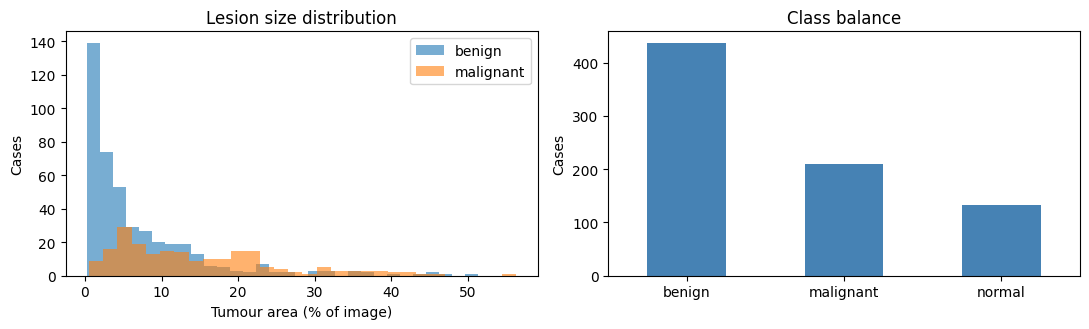

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

tumour_fraction = manifest["tumour_pixels"] / (manifest["height"] * manifest["width"])
for label, group in manifest.groupby("label"):
    if label == "normal":
        continue
    axes[0].hist(tumour_fraction[group.index] * 100, bins=30, alpha=0.6, label=label)
axes[0].set(xlabel="Tumour area (% of image)", ylabel="Cases", title="Lesion size distribution")
axes[0].legend()

manifest["label"].value_counts().plot.bar(ax=axes[1], color="steelblue", rot=0)
axes[1].set(xlabel="", ylabel="Cases", title="Class balance")
fig.tight_layout()
plt.show()

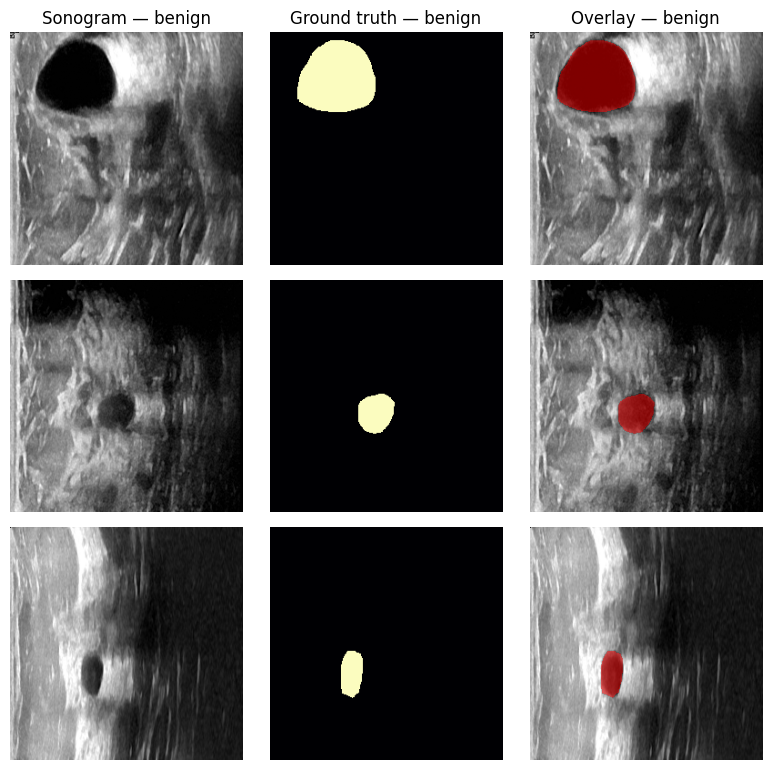

In [ ]:
from busiseg.report import plot_samples

plot_samples(cfg, split="test", n=3)
plt.show()

## 6. Stage 1 — screening

Six architectures, one fold each. Expect roughly 2–3 hours on a T4; the
`swin_unetr` run is the slow one.

Re-running this cell after a disconnect skips whatever already finished.

In [ ]:
from busiseg.benchmark import DEFAULT_MODELS, screen

screening = screen("configs/base.yaml", DEFAULT_MODELS, fold=0)
screening.to_csv(Path(RUNS_DIR) / "screening.csv", index=False)
screening[["model", "dice_mean", "dice_median", "recall_mean", "precision_mean", "fp_rate_on_empty"]].round(4)


=== screening: unet ===



=== screening: attention_unet ===



=== screening: unetpp ===
BasicUNetPlusPlus features: (32, 32, 64, 128, 256, 32).


early stop at epoch 31 (best 0.7675 @ 19)
BasicUNetPlusPlus features: (32, 32, 64, 128, 256, 32).

=== screening: segresnet ===



=== screening: effnet_unet ===


early stop at epoch 39 (best 0.7804 @ 27)

=== screening: swin_unetr ===


early stop at epoch 53 (best 0.7427 @ 41)


,model,dice_mean,dice_median,recall_mean,precision_mean,fp_rate_on_empty
0,unet,0.7732,0.8775,0.7790,0.8139,0.8947
1,attention_unet,0.7619,0.8614,0.7671,0.8080,1.0000
2,effnet_unet,0.7603,0.8971,0.7691,0.7913,0.2105
3,unetpp,0.7492,0.8437,0.7651,0.8029,1.0000
4,segresnet,0.7474,0.8722,0.7557,0.8128,0.9474
5,swin_unetr,0.7373,0.8439,0.7558,0.7874,1.0000


## 7. Stage 2 — cross-validation of the finalists

The top three from screening, retrained on all five folds. This is where the
error bars come from: the spread across folds tells you how much the answer
depends on which images happened to land in training — a different and more
honest question than the per-case confidence interval within a single split.

Budget roughly 3–5 hours. If the session is at risk, run it with `USE_DRIVE`
enabled and let it resume.

In [ ]:
from busiseg.benchmark import cross_validate, leaderboard

N_FINALISTS = 3
finalists = screening["model"].head(N_FINALISTS).tolist()
print("finalists:", finalists)

cv = cross_validate("configs/base.yaml", finalists, cfg.split.n_folds)
cv.to_csv(Path(RUNS_DIR) / "cross_validation.csv", index=False)

board = leaderboard(cv)
board

finalists: ['unet', 'attention_unet', 'effnet_unet']

=== cv: unet fold 0 ===
skip unet_fold0_seed42 (already complete)

=== cv: unet fold 1 ===



=== cv: unet fold 2 ===



=== cv: unet fold 3 ===


early stop at epoch 52 (best 0.7711 @ 40)

=== cv: unet fold 4 ===


early stop at epoch 57 (best 0.7285 @ 45)

=== cv: attention_unet fold 0 ===
skip attention_unet_fold0_seed42 (already complete)

=== cv: attention_unet fold 1 ===


...

early stop at epoch 23 (best 0.7911 @ 11)

=== cv: effnet_unet fold 2 ===


early stop at epoch 31 (best 0.7708 @ 19)

=== cv: effnet_unet fold 3 ===


early stop at epoch 21 (best 0.7834 @ 9)

=== cv: effnet_unet fold 4 ===


early stop at epoch 27 (best 0.7531 @ 15)


,dice_mean,dice_std,recall,precision,fp_rate,n_folds
model,,,,,,
effnet_unet,0.7633,0.0106,0.7802,0.7959,0.5684,5
unet,0.7632,0.0149,0.7822,0.7958,0.9368,5
attention_unet,0.7398,0.0176,0.7623,0.7794,1.0000,5


## 8. Results

### 8.1 The leaderboard

effnet_unet      Dice 0.7633  95% CI [0.7554, 0.7706]
unet             Dice 0.7632  95% CI [0.7516, 0.7747]
attention_unet   Dice 0.7398  95% CI [0.7271, 0.7527]


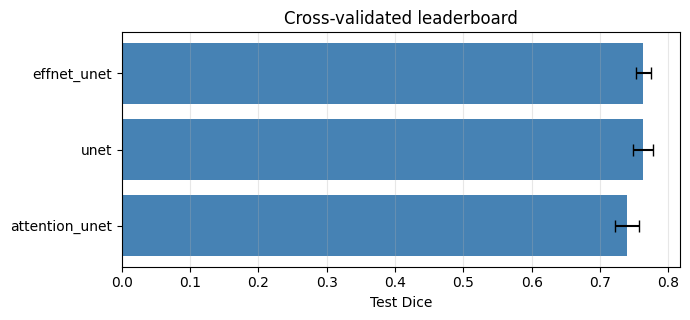

In [ ]:
from busiseg.benchmark import fold_confidence_interval
from busiseg.report import plot_leaderboard

for model in board.index:
    lo, hi = fold_confidence_interval(cv, model)
    print(f"{model:16s} Dice {board.loc[model, 'dice_mean']:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

plot_leaderboard(board)
plt.show()

### 8.2 Learning curves

One fold per finalist. What to look for: validation Dice plateauing well before
the epoch cap (the schedule is long enough), and the train/validation loss gap
(how much the augmentation is holding overfitting back).

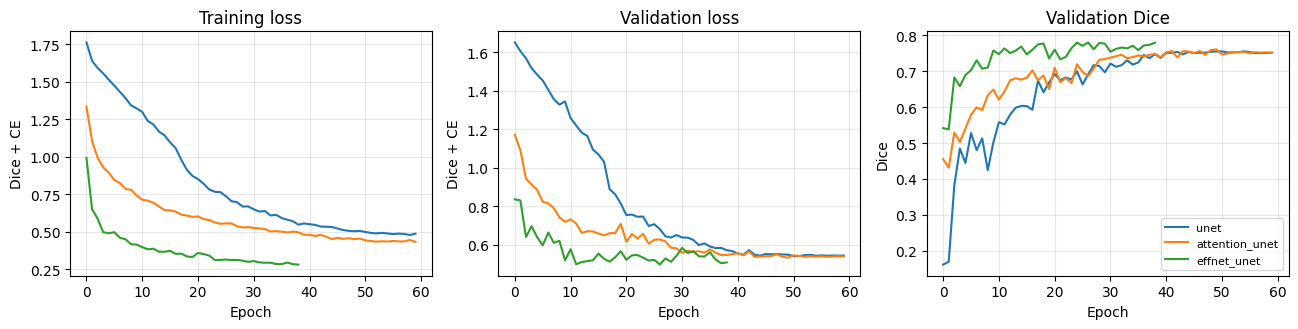

In [ ]:
from busiseg.report import plot_learning_curves

best_model = board.index[0]
curves = {
    row.model: Path(row.run_dir)
    for row in cv.itertuples()
    if row.fold == 0
}
plot_learning_curves(curves)
plt.show()

### 8.3 Per-case distribution

The number that actually matters. A mean Dice of 0.78 is compatible with a model
that is uniformly decent and with one that is excellent on large lesions and
useless on small ones — and only the second is a problem in a clinical setting,
where small lesions are the ones worth catching.

effnet_unet: 540 case-fold scores over 108 test cases


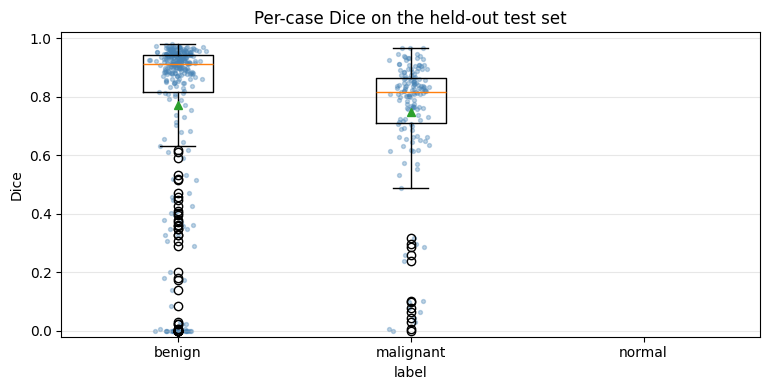

In [ ]:
from busiseg.report import plot_dice_distribution
from busiseg.benchmark import pooled_case_scores

pooled = pooled_case_scores(cv, best_model)
print(f"{best_model}: {len(pooled)} case-fold scores over {pooled['case_id'].nunique()} test cases")

plot_dice_distribution(pooled, by="label")
plt.show()

In [ ]:
import numpy as np

lesions = pooled.dropna(subset=["dice"])
print(f"cases with Dice < 0.5: {(lesions['dice'] < 0.5).mean():.1%}")
print(f"cases with Dice > 0.8: {(lesions['dice'] > 0.8).mean():.1%}")
print(f"\nfalse positives on tumour-free scans: {board.loc[best_model, 'fp_rate']:.1%}")

cases with Dice < 0.5: 14.4%
cases with Dice > 0.8: 70.6%

false positives on tumour-free scans: 56.8%


### 8.4 Qualitative predictions

From the **test** split. The probability map and the thresholded prediction are
shown separately: a soft probability map always looks more convincing than the
binary mask the metric is actually computed on.

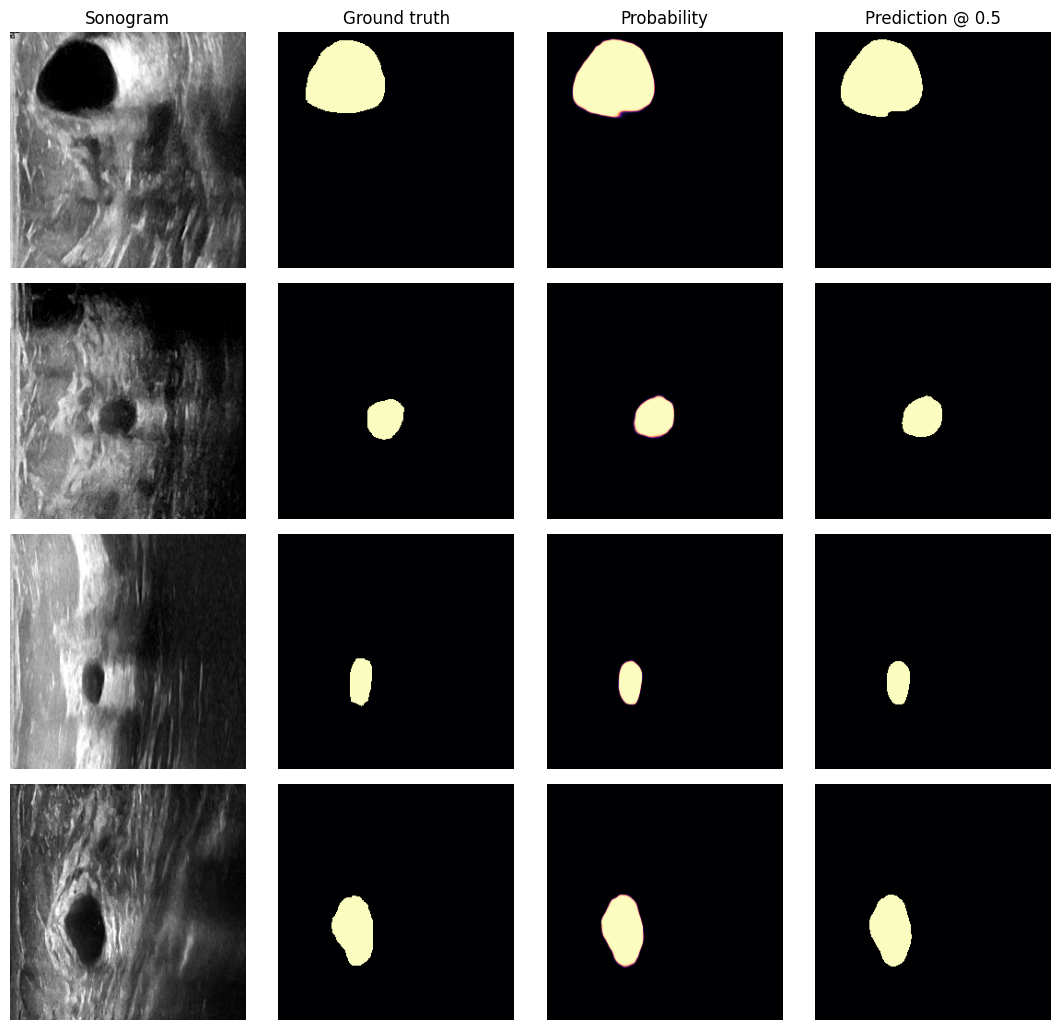

In [ ]:
from busiseg.evaluate import load_run
from busiseg.report import plot_predictions

best_run = cv[(cv["model"] == best_model) & (cv["fold"] == 0)].iloc[0]
best_cfg, best_net = load_run(Path(best_run.run_dir))
best_net = best_net.to("cuda")

plot_predictions(best_cfg, best_net, n=4)
plt.show()

### 8.5 Where it fails

The worst cases are more informative than the best ones. Look for whether the
failures share a property — very small lesions, ill-defined borders, acoustic
shadowing — because that tells you what to fix next.

In [ ]:
worst = (
    pooled.dropna(subset=["dice"])
    .groupby(["case_id", "label"])["dice"]
    .mean()
    .sort_values()
    .head(10)
    .reset_index()
)
worst

,case_id,label,dice
0,benign_247,benign,0.000000
1,benign_313,benign,0.001223
2,malignant_181,malignant,0.063058
3,benign_394,benign,0.065336
4,benign_236,benign,0.073822
5,benign_413,benign,0.112285
6,benign_396,benign,0.129999
7,malignant_80,malignant,0.170642
8,benign_371,benign,0.414560
9,malignant_52,malignant,0.430985


## 9. Conclusions

Fill in from the numbers above rather than from impressions. The claims this
notebook can support:

- A ranking of six architectures under identical training conditions, on a test
  set no model saw during training or model selection.
- Cross-validated means with an across-fold spread, so the gap between the top
  models can be judged against the noise rather than asserted.
- Per-class and per-case behaviour, including the false-positive rate on
  tumour-free scans.

The claims it does **not** support, and which would need more work:

- **Clinical utility.** BUSI is a single-source dataset. Segmentation quality on
  it says nothing about performance on another centre's scanner, and the
  literature is consistent that cross-dataset generalisation in breast
  ultrasound is substantially worse than within-dataset.
- **Per-patient reliability.** BUSI has no patient identifiers, so duplicate
  grouping by image hash is an approximation of grouping by patient. Two scans
  of the same lesion from different angles may still be split.
- **Superiority of the winning architecture in general.** One dataset, one
  training recipe, one image resolution.

### Reasonable next steps

1. **Ensemble the five cross-validation models** — usually worth 1–3 Dice points
   for free, since the checkpoints already exist.
2. **Tune the decision threshold** on validation rather than fixing it at 0.5;
   for small-lesion recall this often matters more than the architecture choice.
3. **Compare against nnU-Net v2** as a ceiling reference. It auto-configures
   preprocessing and architecture and is hard to beat on medical segmentation.
4. **Test on a second dataset** (e.g. BUS-BRA, UDIAT) — the single most
   informative experiment left.

### References

- Oktay et al., 2018, *Attention U-Net: Learning Where to Look for the Pancreas* — [arXiv:1804.03999](https://arxiv.org/abs/1804.03999)
- Al-Dhabyani et al., 2020, *Dataset of breast ultrasound images*, Data in Brief
- Isensee et al., 2021, *nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation*, Nature Methods
- [MONAI](https://monai.io/) — the framework this notebook is built on